In [11]:
# 导入所需库
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

# 配置matplotlib中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [12]:

# ---------------------- 高斯噪声函数 ----------------------
def add_gaussian_noise(image, mean=0, var=0.005):
    img_float = image.astype(np.float64) / 255.0
    noise = np.random.normal(mean, np.sqrt(var), img_float.shape)
    noisy_float = img_float + noise
    noisy_float = np.clip(noisy_float, 0.0, 1.0)
    noisy_image = (noisy_float * 255).astype(np.uint8)
    return noisy_image

# ---------------------- 1. 加载图像 ----------------------
image_path = "../img/kodim23.png"  # 或 "lena.png"
img = cv2.imread(image_path)

if img is None:
    raise FileNotFoundError(f"未找到图片：{image_path}")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ---------------------- 2. 添加高斯噪声 ----------------------
noisy_img_rgb = add_gaussian_noise(img_rgb, var=0.008)
noisy_img_bgr = cv2.cvtColor(noisy_img_rgb, cv2.COLOR_RGB2BGR)

In [13]:

# ---------------------- 3. 滤波参数 ----------------------
# 双边滤波
bilateral_d = 9
bilateral_sigmaColor = 75
bilateral_sigmaSpace = 75

# 导向滤波
gf_r = 5
gf_eps = 0.01 * 255 * 255

In [14]:

# ---------------------- 4. 执行滤波 ----------------------
# 双边滤波
bilateral_result = cv2.bilateralFilter(
    noisy_img_bgr,
    d=bilateral_d,
    sigmaColor=bilateral_sigmaColor,
    sigmaSpace=bilateral_sigmaSpace
)
bilateral_result_rgb = cv2.cvtColor(bilateral_result, cv2.COLOR_BGR2RGB)

# 导向滤波
guide_img_float = img_rgb.astype(np.float32)
noisy_img_float = noisy_img_rgb.astype(np.float32)

gf_result = cv2.ximgproc.guidedFilter(
    guide=guide_img_float,
    src=noisy_img_float,
    radius=gf_r,
    eps=gf_eps
)
gf_result_rgb = np.clip(gf_result, 0, 255).astype(np.uint8)

In [15]:

# ---------------------- 5. 定量指标 ----------------------
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
noisy_gray = cv2.cvtColor(noisy_img_rgb, cv2.COLOR_RGB2GRAY)
bilateral_gray = cv2.cvtColor(bilateral_result_rgb, cv2.COLOR_RGB2GRAY)
gf_gray = cv2.cvtColor(gf_result_rgb, cv2.COLOR_RGB2GRAY)

psnr_noisy = psnr(img_gray, noisy_gray, data_range=255)
psnr_bilateral = psnr(img_gray, bilateral_gray, data_range=255)
psnr_gf = psnr(img_gray, gf_gray, data_range=255)

ssim_noisy = ssim(img_gray, noisy_gray, data_range=255)
ssim_bilateral = ssim(img_gray, bilateral_gray, data_range=255)
ssim_gf = ssim(img_gray, gf_gray, data_range=255)

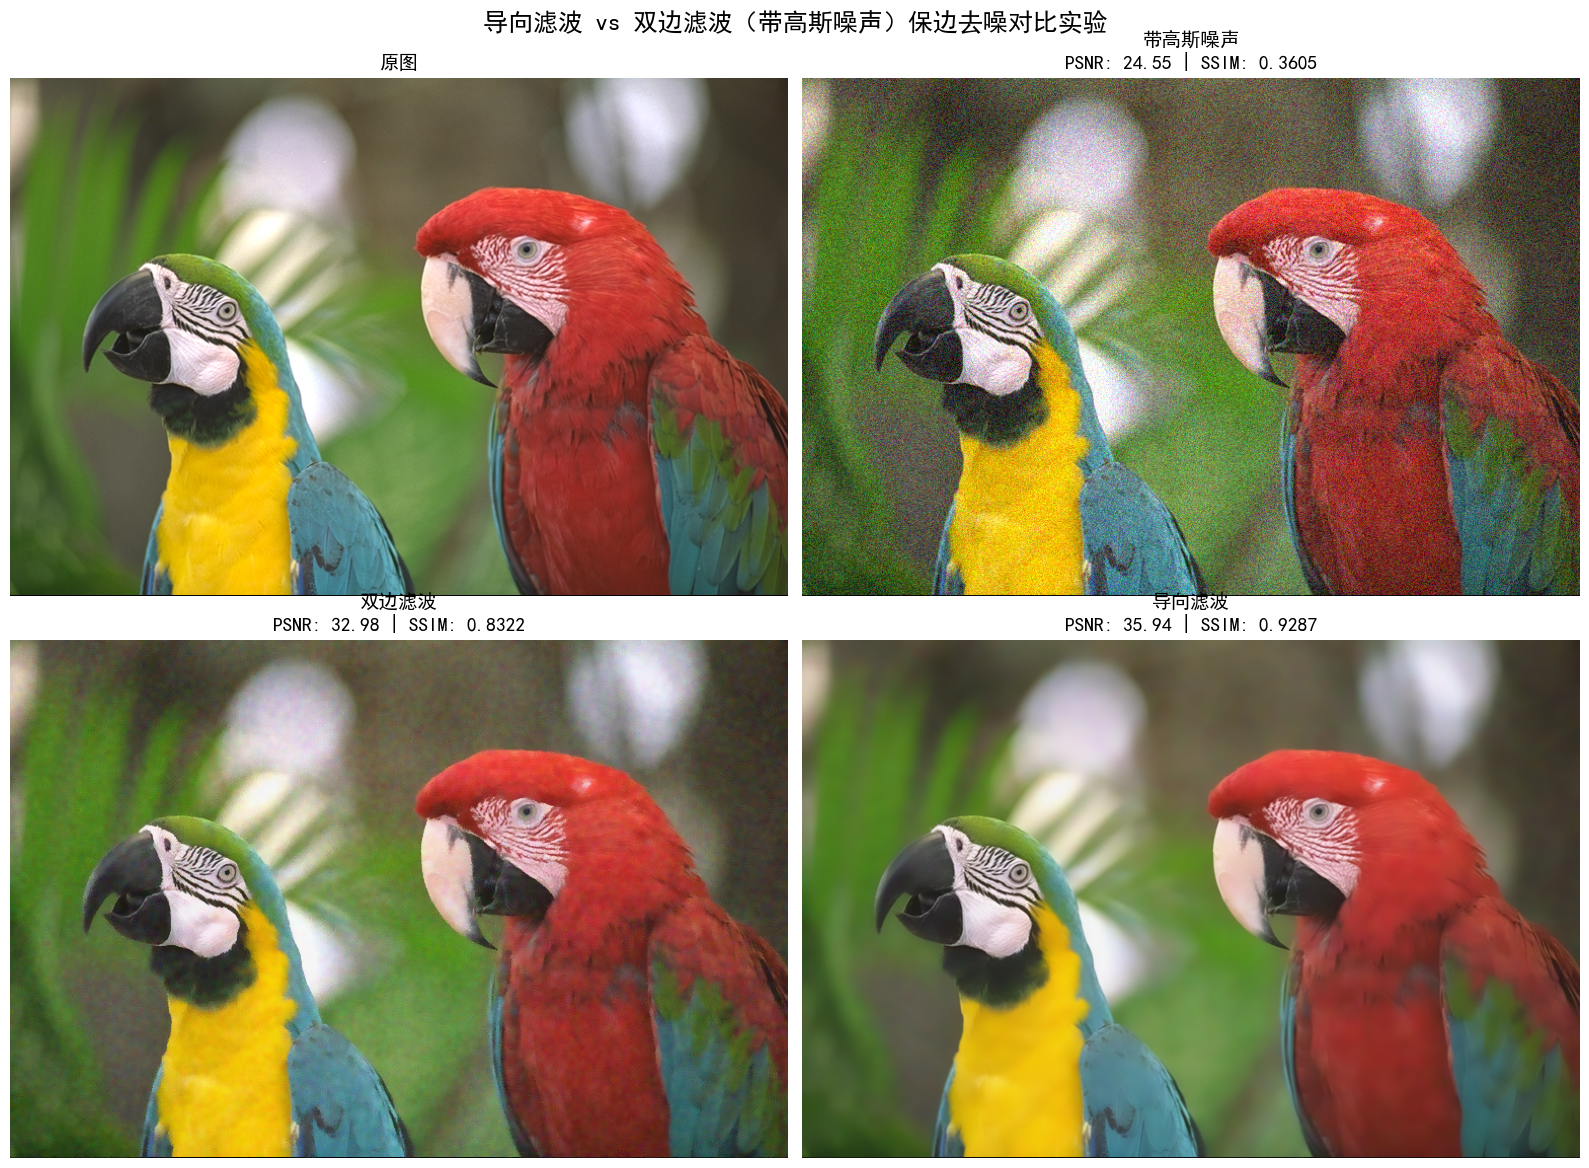

In [16]:

# ---------------------- 6. 2×2 布局可视化 ----------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 左上：原图
axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title("原图", fontsize=14)
axes[0, 0].axis("off")

# 右上：带噪图
axes[0, 1].imshow(noisy_img_rgb)
axes[0, 1].set_title(
    f"带高斯噪声\nPSNR: {psnr_noisy:.2f} | SSIM: {ssim_noisy:.4f}",
    fontsize=14
)
axes[0, 1].axis("off")

# 左下：双边滤波
axes[1, 0].imshow(bilateral_result_rgb)
axes[1, 0].set_title(
    f"双边滤波\nPSNR: {psnr_bilateral:.2f} | SSIM: {ssim_bilateral:.4f}",
    fontsize=14
)
axes[1, 0].axis("off")

# 右下：导向滤波
axes[1, 1].imshow(gf_result_rgb)
axes[1, 1].set_title(
    f"导向滤波\nPSNR: {psnr_gf:.2f} | SSIM: {ssim_gf:.4f}",
    fontsize=14
)
axes[1, 1].axis("off")

plt.suptitle("导向滤波 vs 双边滤波（带高斯噪声）保边去噪对比实验", fontsize=18)
plt.tight_layout()
plt.show()

In [17]:

# ---------------------- 7. 结果总结 ----------------------
print("2×2 布局保边去噪对比实验总结")
print(f"PSNR 排序：导向滤波 {psnr_gf:.2f} > 双边滤波 {psnr_bilateral:.2f} > 带噪图 {psnr_noisy:.2f}")
print(f"SSIM 排序：导向滤波 {ssim_gf:.4f} > 双边滤波 {ssim_bilateral:.4f} > 带噪图 {ssim_noisy:.4f}")
print("\n结论：导向滤波在去噪与保边的综合表现上明显优于双边滤波。")

2×2 布局保边去噪对比实验总结
PSNR 排序：导向滤波 35.94 > 双边滤波 32.98 > 带噪图 24.55
SSIM 排序：导向滤波 0.9287 > 双边滤波 0.8322 > 带噪图 0.3605

结论：导向滤波在去噪与保边的综合表现上明显优于双边滤波。
